# K-MEANS Clustering

## Initialization

### Import Packages

In [1]:
## Set up
## Import Packages
import warnings
import os

import pandas as pd
import numpy as np
import re # Regular Expressions

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches

import seaborn as sns
import plotly.express as px

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, fowlkes_mallows_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import scipy
from scipy.spatial.distance import cdist
from scipy.stats import norm, skew, kurtosis, spearmanr
from scipy.optimize import linear_sum_assignment

# Time functions
import time
 
# Suppress Future Warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Suppress print() in functions
import contextlib
import io

def suppress_prints(func, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return func(*args, **kwargs)

# Specify Paths
figure_storage = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_KMeans++/Figures"
data_storage = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_KMeans++"

# Select Random Seed
RandomSeed = 42
print(f'Random seed is set to {RandomSeed}. Cluster algorithms and Neural Networks are optimization algorithms. Therefore the seed affects the initialization and so the model performance.')

Random seed is set to 42. Cluster algorithms and Neural Networks are optimization algorithms. Therefore the seed affects the initialization and so the model performance.


## CHOOSE SETTINGS

In [2]:
grid_search = True

### Import Dataset

In [3]:
## Import Dataset
psaid12 = pd.read_csv('/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv') # Import dataset
psaid12.head() # Check data

## Define Varlists
columns_gp = [i for i in psaid12.columns if re.match(r'^gp\d{2}$',i)]

## Dictionary
domains_dict = {
    'gp01': 'Pain',
    'gp02': 'Fatigue',
    'gp03': 'Skin',
    'gp04': 'Work-recreational activities',
    'gp05': 'Bodily functioning',
    'gp06': 'Discomfort',
    'gp07': 'Sleep',
    'gp08': 'Coping',
    'gp09': 'Anxiety',
    'gp10': 'Shame',
    'gp11': 'Social activities',
    'gp12': 'Depression'
}

## Codebook 
# print(f' The imported PsAID dataset contains {len(psaid12)} datapoints')
# psaid_codebook = pd.DataFrame({
#     'Variable' : psaid12.columns.tolist(),
#     'Data_type' : psaid12.dtypes.tolist(),
#     'Description' : ['Participant', 'Moment of measurement', 'Date of completion', 'Q1 pain', 'Q2 fatigue', 'Q3 skin', 'Q4 work-recreational activities', 'Q5 bodily functioning', 'Q6 discomfort', 'Q7 sleep', 'Q8 coping', 'Q9 anxiety','Q10 shame', 'Q11 social activities', 'Q12 depression', 'PsAID12 Total score'],
#     'Exact Question': [ '-',
#                         '-',
#                         '-',
#                         'Kies het getal dat het beste de pijn beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van vermoeidheid beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de huidproblemen (inclusief jeuk) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden beschrijft die u ondervond om volwaardig deel te nemen aan werk- en/of vrije tijdsactiviteiten als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden met dagelijkse lichamelijke activiteiten beschrijft die u ondervond als gevolg van van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste het gevoel van ongemak en ergernis bij alledaagse activiteiten beschrijft als gevolg van uw artritis psoriatica in de afgelopen week.',
#                         'Kies het getal dat het beste de slaapproblemen (bijv. uw nachtrust) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kijkend naar uw artritis psoriatica in het algemeen, hoe goed kon u met uw ziekte omgaan gedurende de afgelopen week?',
#                         'Kies het getal dat het beste de mate van angst, bezorgdheid en onzekerheid (bijv. over de toekomst, behandelingen, angst voor eenzaamheid) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Uw artritis psoriatica in het algemeen genomen, kies het getal dat het beste de mate van schaamte beschrijft die u ondervond als gevolg van de zichtbaarheid van uw ziekte gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de problemen beschrijft die u had om volledig aan sociale activiteiten deel te nemen (inclusief relaties met familie en vrienden) als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van depressie en/of neerslachtigheid beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         '-'
#                         ]
# })
# psaid_codebook 

In [4]:
psaid12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 37 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   respondentid  5099 non-null   int64  
 1   mm            5099 non-null   int64  
 2   submitdate    5099 non-null   object 
 3   gp01          5099 non-null   int64  
 4   gp02          5099 non-null   int64  
 5   gp03          5099 non-null   int64  
 6   gp04          5099 non-null   int64  
 7   gp05          5099 non-null   int64  
 8   gp06          5099 non-null   int64  
 9   gp07          5099 non-null   int64  
 10  gp08          5099 non-null   int64  
 11  gp09          5099 non-null   int64  
 12  gp10          5099 non-null   int64  
 13  gp11          5099 non-null   int64  
 14  gp12          5099 non-null   int64  
 15  psaid12       5099 non-null   float64
 16  Geslacht      5094 non-null   object 
 17  age           5094 non-null   float64
 18  bmi           2653 non-null 

## Determine Configurations

References: 
* Kmeans: https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.k_means.html 
* Elbow Method: https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/#implementation-of-the-elbow-method-usking-sklearn-in-python 

### Grid Search

In [41]:
# Define Grid Search K-Means function
def grid_search_kmeans(data, n_clusters_range, n_init_range, RandomSeed):
    """
    Performs grid search over KMeans hyperparameters `n_clusters` and `n_init`, 
    and returns the best configuration based on silhouette score.
 
    Parameters:
    - psaid (pd.DataFrame): Input dataset for clustering.
    - n_clusters_range (range or list): Range of number of clusters to test.
    - n_init_range (list): Range of `n_init` values to test.
    - max_iter (int): Maximum number of iterations for KMeans (default=300).
    - tol (float): Tolerance for convergence (default=1e-4).
    
    Returns:
    - pd.DataFrame: Sorted DataFrame with hyperparameter combinations and silhouette scores.
    """
   
    results = []  # Store results here

    # Grid search loop over n_clusters and n_init
    for n_clusters in n_clusters_range:
        for n_init in n_init_range:
            
            # Initialize and fit the KMeans model
            kmeans = KMeans(
                n_clusters=n_clusters,
                init='k-means++',
                n_init=n_init,
                random_state= RandomSeed
            )
            
            # Fit the model and get the predicted labels
            labels = kmeans.fit_predict(data)
            
            # Compute scores
            inertia = kmeans.inertia_
            s_score = silhouette_score(data, labels)
            ch_index = calinski_harabasz_score(data, labels)
            db_index = davies_bouldin_score(data, labels)
            
            # Append results
            results.append({
                'n_clusters': n_clusters,
                'n_init': n_init,
                'WCSS': inertia,                  # Lower values indicate more compact clusters
                'silhouette_score': s_score,      # Higher values indicate better separation
                'calinski_harabasz': ch_index,    # Higher values indicate better separation. Within-cluster compactness vs the between-cluster dispersion.
                'davies_bouldin': db_index        # Lower values indicate clusters are distinct. Measures average similarity between each cluster and its most similar other cluster
            })

    # Convert results to a DataFrame and sort by silhouette score
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='silhouette_score', ascending=False)

    return results_df



# Analyze Grid Search Results
def analyze_grid_search_results(df):
    """
    Analyzes a DataFrame of grid search results for KMeans clustering.
    For each n_clusters, it determines the lowest n_init for each metric,
    and compares the results of higher n_init values against the reference.
    
    Parameters:
    - df (pd.DataFrame): DataFrame with columns: 
        ['n_clusters', 'n_init', 'WCSS', 'Silhouette_score', 'Calinski_Harabasz', 'Davies_Bouldin']
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a column indicating whether higher n_init is "better" or "worse".
    """
    # Create a copy of the dataframe to work with
    results_df = df.copy()
    
    # For each number of clusters, find the minimum n_init based on each metric
    for n_clusters in results_df['n_clusters'].unique():
        
        # Filter the results for the current number of clusters
        cluster_results = results_df[results_df['n_clusters'] == n_clusters]

        # Find the reference values (for n_init=1) for each metric
        reference_row = cluster_results[cluster_results['n_init'] == min(cluster_results['n_init'])]

        if not reference_row.empty:
            
             # Find the reference for each metric
            ref_wcss = reference_row['WCSS'].values[0]
            ref_sil = reference_row['silhouette_score'].values[0]
            ref_ch = reference_row['calinski_harabasz'].values[0]
            ref_db = reference_row['davies_bouldin'].values[0]
        
            # Use .loc[] to ensure proper assignment to the DataFrame
            results_df.loc[results_df['n_clusters'] == n_clusters, 'WCSS_difference'] = results_df.loc[results_df['n_clusters'] == n_clusters, 'WCSS'].apply(
                lambda x: round(x - ref_wcss, 6)
            )
            results_df.loc[results_df['n_clusters'] == n_clusters, 'Silhouette_difference'] = results_df.loc[results_df['n_clusters'] == n_clusters, 'silhouette_score'].apply(
                lambda x: round(x - ref_sil, 6)
            )
            results_df.loc[results_df['n_clusters'] == n_clusters, 'CH_difference'] = results_df.loc[results_df['n_clusters'] == n_clusters, 'calinski_harabasz'].apply(
                lambda x: round(x - ref_ch, 6)
            )
            results_df.loc[results_df['n_clusters'] == n_clusters, 'DB_difference'] = results_df.loc[results_df['n_clusters'] == n_clusters, 'davies_bouldin'].apply(
                lambda x: round(x - ref_db, 6)
            )

        # Set the difference columns to NaN for the reference row
        results_df.loc[results_df['n_init'] == min(cluster_results['n_init']), 'WCSS_difference'] = np.nan
        results_df.loc[results_df['n_init'] == min(cluster_results['n_init']), 'Silhouette_difference'] = np.nan
        results_df.loc[results_df['n_init'] == min(cluster_results['n_init']), 'CH_difference'] = np.nan
        results_df.loc[results_df['n_init'] == min(cluster_results['n_init']), 'DB_difference'] = np.nan
    
    return results_df


In [42]:
# Grid search ranges

if grid_search:
    n_clusters_range = range(2, 30)
    n_init_range = [1, 5, 10, 20, 100]
    # max_iter_range = [100, 300, 500] # When disabled max_iter = 300 (default)
    # tol_range = [1e-2, 1e-3, 1e-4] # When disabled tolerance is 1e-4 (default)
    
    ## TO TEST FUNCTIONS
    # n_clusters_range = range(2, 4)
    # n_init_range = [1, 5]
    
    # Run Grid Search
    configs_results = grid_search_kmeans(psaid12[columns_gp], n_clusters_range, n_init_range, RandomSeed).sort_values(['n_clusters', 'n_init'])
    configs_results_formatted = analyze_grid_search_results(configs_results)
    
    """"
    WCSS: Lower values indicate more compact clusters
    silhouette_score:  Higher values indicate better separation
    calinski_harabasz: Higher values indicate better separation. Within-cluster compactness vs the between-cluster dispersion.
    davies_bouldin: Lower values indicate clusters are distinct. Measures average similarity between each cluster and its most similar other cluster
    """
    configs_results_formatted

### Auto # Initiations

In [43]:
def kmeans_autoinit(data, n_clusters_range, RandomSeed):
    
    results = []  # Store results here

    # Grid search loop over n_clusters and n_init
    for n_clusters in n_clusters_range:
            # Initialize and fit the KMeans model
            kmeans = KMeans(
                n_clusters=n_clusters,
                init='k-means++',
                n_init='auto',
                random_state= RandomSeed
            )
            
            # Fit the model and get the predicted labels
            labels = kmeans.fit_predict(data)
            
            # Compute scores
            inertia = kmeans.inertia_
            s_score = silhouette_score(data, labels)
            ch_index = calinski_harabasz_score(data, labels)
            db_index = davies_bouldin_score(data, labels)
            
            # Append results
            results.append({
                'n_clusters': n_clusters,
                'n_init': kmeans.n_iter_,
                'WCSS': inertia,                  # Lower values indicate more compact clusters
                'silhouette_score': s_score,      # Higher values indicate better separation
                'calinski_harabasz': ch_index,    # Higher values indicate better separation. Within-cluster compactness vs the between-cluster dispersion.
                'davies_bouldin': db_index        # Lower values indicate clusters are distinct. Measures average similarity between each cluster and its most similar other cluster
            })

    # Convert results to a DataFrame and sort by silhouette score
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='silhouette_score', ascending=False)

    return results_df

In [44]:
if grid_search:
    results_autoinit = kmeans_autoinit(psaid12[columns_gp], n_clusters_range, RandomSeed).sort_values('n_clusters')
    results_autoinit

In [45]:
results_autoinit

,n_clusters,n_init,WCSS,silhouette_score,calinski_harabasz,davies_bouldin
0,2,8,208997.202452,0.468633,5452.299636,0.909980
1,3,17,163291.381803,0.368114,4201.724141,1.239104
2,4,17,145985.294807,0.304502,3333.932225,1.502774
3,5,31,137053.382745,0.259822,2745.878988,1.791101
4,6,66,130213.356012,0.261357,2365.144843,1.781826
5,7,26,125627.901452,0.221948,2073.480449,1.918358
6,8,44,120947.716846,0.227385,1873.817354,1.896219
7,9,42,116454.564697,0.233160,1727.060292,1.875169
8,10,47,112894.990009,0.229266,1601.085716,1.855219
9,11,42,110442.921778,0.192750,1483.979225,1.860849


### Plot Internal Cluster Quality Scores

In [46]:
def plot_score(pivot_df, score, auto_init_df):
    # Pivot the DataFrame to have 'n_clusters' as the index and 'n_init' as the columns
    pivot_df = configs_results[['n_clusters', 'n_init', score]].pivot(index='n_clusters', columns='n_init', values= score)
    
    # ---- Plot 1: From elbow_df (fixed n_init values) ----
    ax = pivot_df.plot(figsize=(10, 6), marker='o')
    
    # ---- Plot 2: From results_autoinit (auto-init strategy) ----
    # Plot it as an additional line on the same axes
    ax.plot(auto_init_df['n_clusters'], results_autoinit[score], marker='s', linestyle='--', color='black', label='Auto-init')
    
    # Label the plot
    ax.set_title(f'{score} vs. Number of Clusters')
    ax.set_xlabel('# Clusters')
    ax.set_ylabel(f'{score}')
    ax.legend(title='# Initiations', loc='best')

    # Set grid and ticks
    cluster_ticks = sorted(auto_init_df['n_clusters'].unique())
    ax.set_xticks(cluster_ticks)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Save Images
    plt.savefig(os.path.join(figure_storage, f'PsAID_KMeans++_{score} vs. Number of Clusters.png'))


#### WCSS

_Within-Cluster Sum of Squares (WCSS)_: a metric used to evaluate the compactness of clusters in clustering algorithms, such as k-means. It measures the sum of squared distances between each data point and the centroid of its assigned cluster. The WCSS helps to determine how well the clusters are formed. WCSS is calculated as the sum of the squared distances between each data point and the centroid of the cluster it belongs to.  
Low WCSS: Indicates that data points are close to their cluster centroids, suggesting that the clusters are compact and well-formed.  
High WCSS: Indicates that data points are spread out from their cluster centroids, suggesting that the clusters are not well-formed.

> $\text{WCSS} = \sum_{i=1}^k \sum_{x \in C_i} \| x - \mu_i \|^2$
> - $ k $: The number of clusters.
> - $ C_i $: The set of points in cluster $i$.
> - $ | x - \mu_i| $ is the Euclidean distance between the datapoint $x$ and the centroid $\mu_i$.

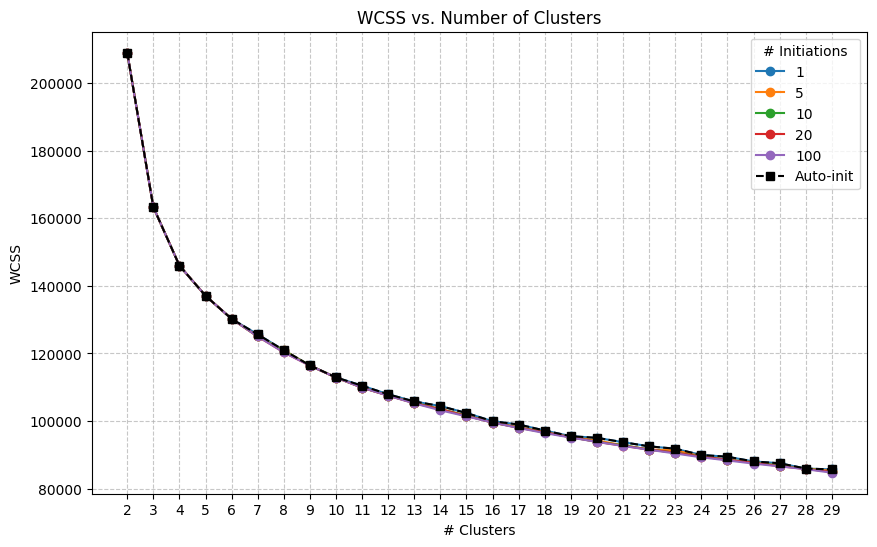

In [47]:
if grid_search: 
    plot_score(configs_results, score = 'WCSS', auto_init_df = results_autoinit)

#### CH-Index

_Calinski-Harabasz Index_ = _Variance Ratio Criterion_: a valuable metric for assessing the quality of clustering. It balances the compactness and separation of clusters, providing a single value that indicates how well the data points are grouped into distinct clusters. By maximizing the ratio of between-cluster dispersion and minimizing the within-cluster dispersion, the Calinski-Harabasz Index helps in selecting the optimal number of clusters and evaluating the performance of different clustering algorithms. 

> $ \text{CH Index} = \frac{\text{Tr}(B_k)}{\text{Tr}(W_k)} \cdot \frac{N - k}{k - 1} $
> - $Tr(B_{k}​)$: is the trace of the between-cluster dispersion matrix
> - $Tr(W_{k}​)$: is the trace of the within-cluster dispersion matrix
> - $N$: is the total number of data points.
> - $k$: is the total number of clusters

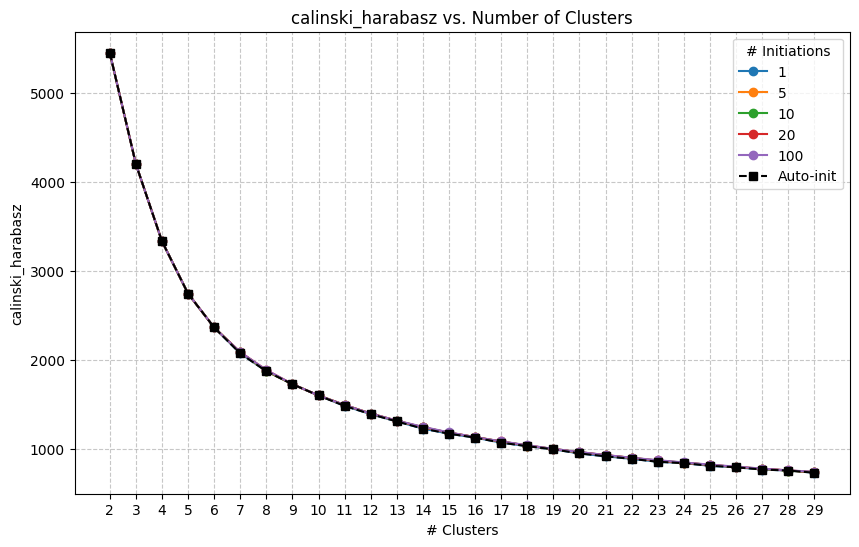

In [48]:
if grid_search: 
    plot_score(configs_results, score = 'calinski_harabasz', auto_init_df = results_autoinit)

#### Average Silhouette Score

_Silhoutte Score_: a metric used to evaluate the quality of a clustering algorithm, such as K-Means. It measures how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where: +1 indicates that the sample is far away from the neighboring clusters and very close to the cluster it is assigned to. 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters. -1 indicates that the sample might have been assigned to the wrong cluster, as it is closer to a neighboring cluster than to the cluster it is assigned to. 

> $ s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $
> - $a(i)$: The average distance between point 𝑖 and all other points in the same cluster.
> - $b(i)$: The average distance between point 𝑖 and all points in the nearest cluster to which 𝑖 does not belong.

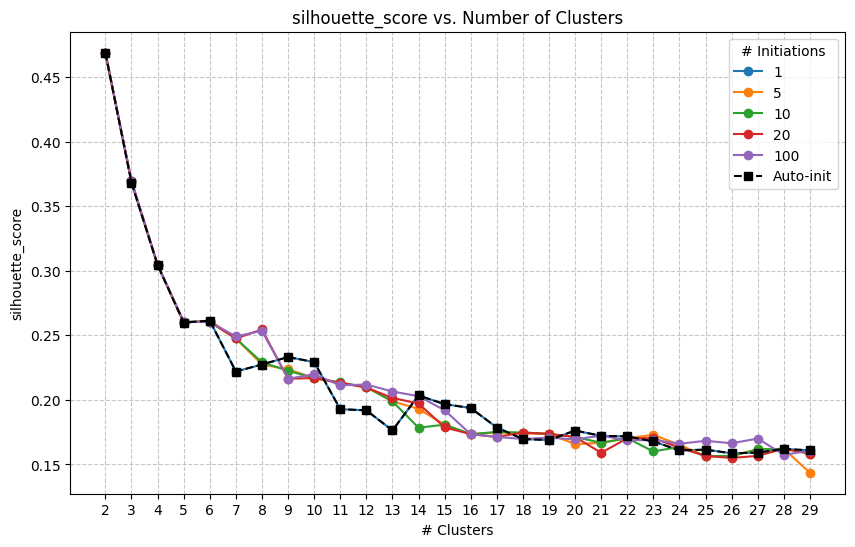

In [49]:
if grid_search: 
    plot_score(configs_results, score = 'silhouette_score', auto_init_df = results_autoinit)

#### DB_Index

_Davies-Bouldin Index (DBI)_: is a metric used to evaluate the quality of clustering algorithms. It measures the average similarity ratio of each cluster with its most similar cluster, taking into account both intra-cluster similarity (compactness) and inter-cluster difference (separation).
Lower values of the Davies-Bouldin Index indicate better clustering quality.

> $DBI = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{s_i + s_j}{d(c_i, c_j)} \right)$
> - $k$: Number of clusters.
> - $𝑠_{𝑖}$: The average distance between all points in cluster 𝑖and the centroid of cluster 𝑖. This is a measure of the scatter (or compactness) of the cluster.
> > $s_i = \frac{1}{|C_i|} \sum_{x \in C_i} \|x - c_i\|$
> > - $C_i$: is the set of points in cluster $i$.
> > - $c_i$: is the centroid of cluster $i$.
> > - $| x - c_i |$: is the distance between point $x$ and the centroid $c_i$.
> > - $ d(c_i, c_j) $: The distance between the centroids of clusters $i$ and $j$, which represents the separation between clusters.

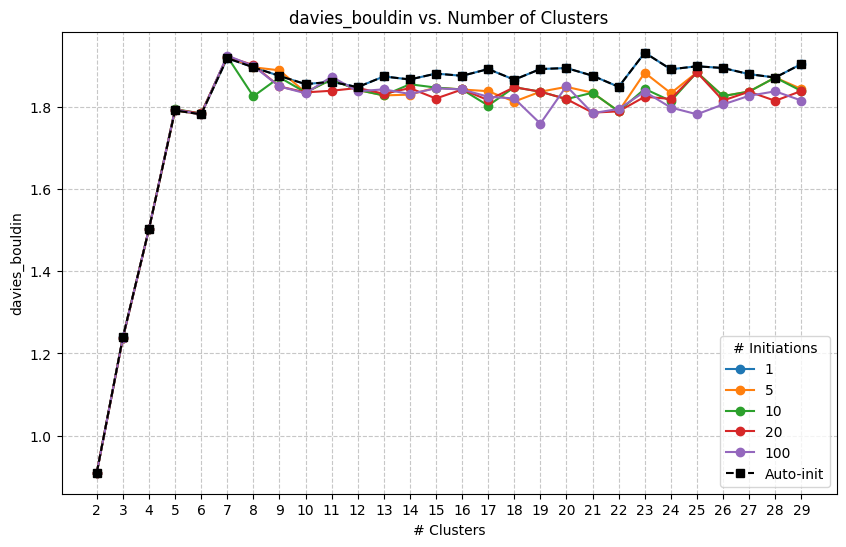

In [50]:
if grid_search: 
    plot_score(configs_results, score = 'davies_bouldin', auto_init_df = results_autoinit)

## Compute Clusters, K = [3, 4, 5, 6]

#### Run Clustering Algoritm

In [51]:
def run_clustering(data, n_clusters, RandomSeed, byvar):   
    # Initialize and fit the KMeans model
    kmeans = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init='auto',
        random_state= RandomSeed
    )

    data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
    cluster_centers = kmeans.cluster_centers_ # Store cluster center in cluster_centers dictionary

    return data, cluster_centers
    del kmeans #Ensure the model is forgotten after each iteration

In [52]:
# Compute clusters for K = 3, 4, 6 & 7
cluster_centers_dict = {}

psaid12, cluster_centers_dict[3] = run_clustering(psaid12, 3, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[4] = run_clustering(psaid12, 4, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[5] = run_clustering(psaid12, 5, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[6] = run_clustering(psaid12, 6, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[7] = run_clustering(psaid12, 7, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[8] = run_clustering(psaid12, 8, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[9] = run_clustering(psaid12, 9, RandomSeed, columns_gp)
psaid12, cluster_centers_dict[10] = run_clustering(psaid12, 10, RandomSeed, columns_gp)

In [53]:
cluster_columns = [i for i in psaid12.columns if re.match(r'^clusterID_',i)]
cluster_columns

['clusterID_k3',
 'clusterID_k4',
 'clusterID_k5',
 'clusterID_k6',
 'clusterID_k7',
 'clusterID_k8',
 'clusterID_k9',
 'clusterID_k10']

## Evaluate Clustering Quality

In [54]:
psaid12.head()

,respondentid,mm,submitdate,gp01,gp02,gp03,gp04,gp05,gp06,gp07,...,psaid_state,pass_state,clusterID_k3,clusterID_k4,clusterID_k5,clusterID_k6,clusterID_k7,clusterID_k8,clusterID_k9,clusterID_k10
0,78195329,36,2019-03-31 22:06:01,2,2,2,2,2,0,1,...,1,0,1,1,1,1,4,2,2,2
1,10862915,6,2019-02-06 14:26:32,1,6,2,1,1,1,1,...,1,0,1,2,4,4,4,2,2,2
2,29370588,18,2016-01-06 13:28:33,6,7,5,6,4,6,7,...,3,1,0,0,3,3,6,7,7,7
3,87648336,18,2016-08-18 00:05:35,0,4,5,0,0,0,0,...,0,0,1,1,1,1,1,1,8,8
4,42677901,84,2022-04-25 21:30:01,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,1,1,1


#### Cluster sizes and variance

In [55]:
desc = [] 

def cluster_size_spread(data, cluster_assignment, byvar, desc):
    """

    """
    cluster_centers_mean = pd.DataFrame()
    cluster_size = pd.DataFrame()
    cluster_spread = pd.DataFrame()

    cluster_size = pd.Series(data[cluster_assignment]).value_counts().sort_index().values # Compute cluster sizes

    # Determine cluster Variance
    cluster_spread = pd.Series(data.groupby(cluster_assignment)[byvar]
            .var()  # Compute variance for each cluster
            .mean(axis=1)).values  # Average variance across all dimensions

    # Store data
    desc.append({
                    'Algorithm': cluster_assignment,
                    '# Clusters': f'{data[cluster_assignment].nunique()}',
                    'Cluster Sizes': f'{cluster_size}' ,
                    'Cluster Variances': f'{np.round(cluster_spread, 2)}',
                })

    # print(f'{describe_clusters}')
    # print(f'Cluster Sizes: {cluster_size}')
    # print(f'Cluster Variances: {cluster_spread} \n')

    return cluster_size, cluster_spread, desc

In [56]:
for describe_clusters in cluster_columns:
    cluster_size, cluster_spread, desc = cluster_size_spread(psaid12, describe_clusters, columns_gp, desc)

pd.DataFrame(desc)

,Algorithm,# Clusters,Cluster Sizes,Cluster Variances
0,clusterID_k3,3,[ 979 2575 1545],[4.55 1.27 3.82]
1,clusterID_k4,4,[ 563 2180 1357 999],[3.66 0.88 3.07 4.05]
2,clusterID_k5,5,[ 385 1930 875 721 1188],[3.02 0.67 3.53 3.96 2.56]
3,clusterID_k6,6,[ 426 1909 683 532 1158 391],[3.78 0.66 3.23 3.6 2.36 2.96]
4,clusterID_k7,7,[ 420 1674 661 508 1055 267 514],[3.73 0.5 2.7 3.42 1.98 2.5 3.52]
5,clusterID_k8,8,[ 418 1689 1057 422 282 331 588 312],[3.38 0.51 1.94 3.25 2.47 3.22 2.77 3.21]
6,clusterID_k9,9,[ 371 1689 874 392 269 321 545 301 337],[3.2 0.49 1.68 3.29 2.42 3.2 2.66 3.11 2.67]
7,clusterID_k10,10,[ 343 1624 884 367 268 336 367 288 316 ...,[2.64 0.44 1.54 3.15 2.39 3.18 2.48 3.12 2.55 ...


#### Partitioning - Silhouette Plots

In [57]:
def compute_silhouette_plot(data, K, columns_gp):
    """
    Function that calculates and plots the silhouette score for each cluster and their average score.
    It measures how similar an object is to its own cluster compared to other clusters.
    """ 
    print("""Cluster silhouette scores: \n 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned \n""")
    
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-1, 1])
    ax1.set_ylim([0, len(data) + (K + 1) * 10])   # The (k+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    
    # Average Silhouette score for all samples.
    # This gives a perspective into the density and separation of the formed clusters
    cluster_assignment = data[f'clusterID_k{K}'] 
    silhouette_avg = silhouette_score(data[columns_gp], cluster_assignment) # Compute
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")  # Plot the vertical line for average silhouette score of all the values
    print(f' Average: {silhouette_avg}')
    
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(data, cluster_assignment)

    y_lower = 10
    for i in range(K):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        silhouette_values_i = sample_silhouette_values[cluster_assignment == i] # Subset
        silhouette_values_i.sort() #Sort values

        # Calculate average silhouette score of the cluster
        silhouette_avg_i = silhouette_values_i.mean()
        print(f' Average cluster {i}: {silhouette_avg_i}')

        # Calculate cluster size
        size_cluster_i = silhouette_values_i.shape[0]
        y_upper = y_lower + size_cluster_i

        # Format Colors
        spectral_palette = sns.color_palette("Spectral", K)
        # desired_order_colors = [2, 3, 1, 0, 4, 5]
            # Cluster 0 - Light green - ColorID 2
            # Cluster 1 - Dark green - ColorID 3
            # Cluster 2 - Yellow - ColorID 0
            # Cluster 3 - Red - ColorID 1
        color = spectral_palette #[spectral_palette[i] for i in desired_order_colors][i]
        
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            silhouette_values_i,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
    
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.1, y_lower + 0.5 * size_cluster_i, f'{i} ({size_cluster_i})')
    
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    # Format Graph
    ax1.set_title(f'The average silhouette_score is : {silhouette_avg}')
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks(np.arange(-1, 1.2, 0.2))
    
    plt.suptitle(f"Silhouette analysis for k = {K}", fontsize=14, fontweight="bold")
    plt.savefig(os.path.join(figure_storage, f'PsAID_KMeans++_Silhouette_K{K}.png'))
    plt.show()

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.36811417644404937
 Average cluster 0: 0.27079525465479815
 Average cluster 1: 0.5583380690363775
 Average cluster 2: 0.12908434411301234


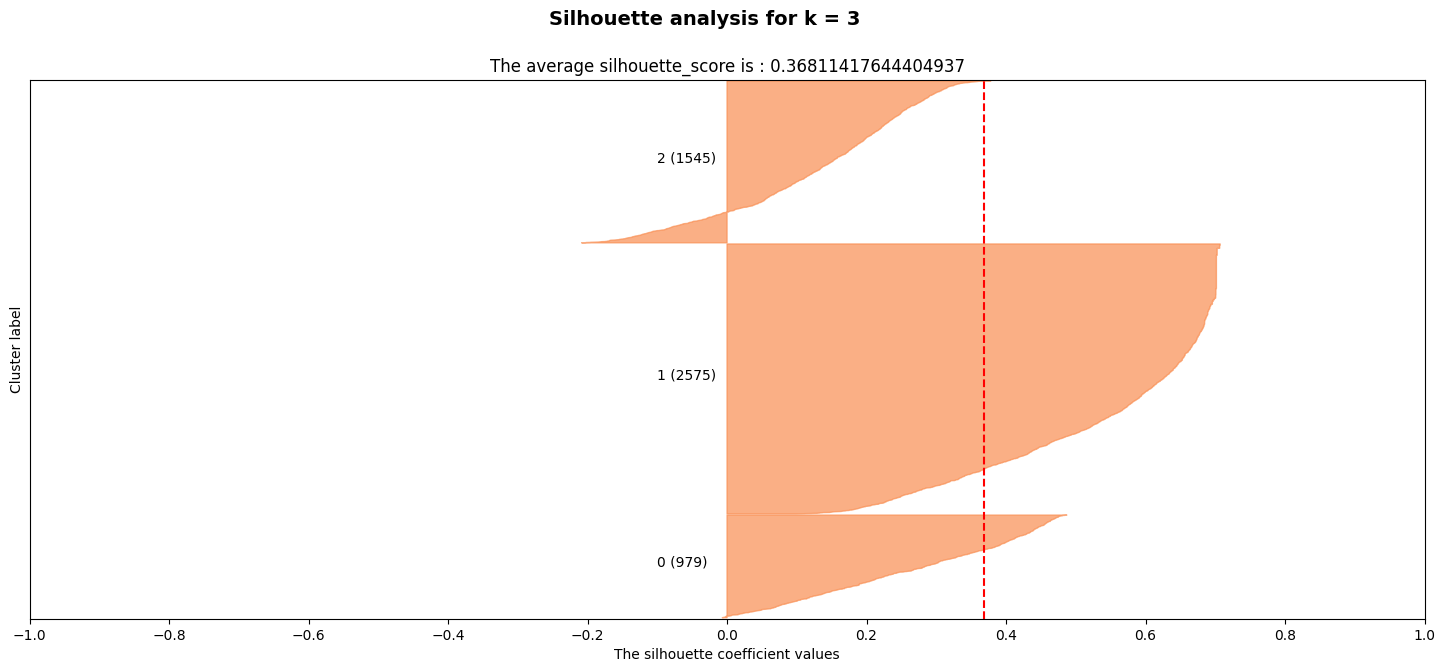

In [58]:
## Compute Results K = 3
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k3']], 3, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.3045018268401685
 Average cluster 0: 0.29807339341663186
 Average cluster 1: 0.5541361184294478
 Average cluster 2: 0.07135106655120911
 Average cluster 3: 0.12475893061990201


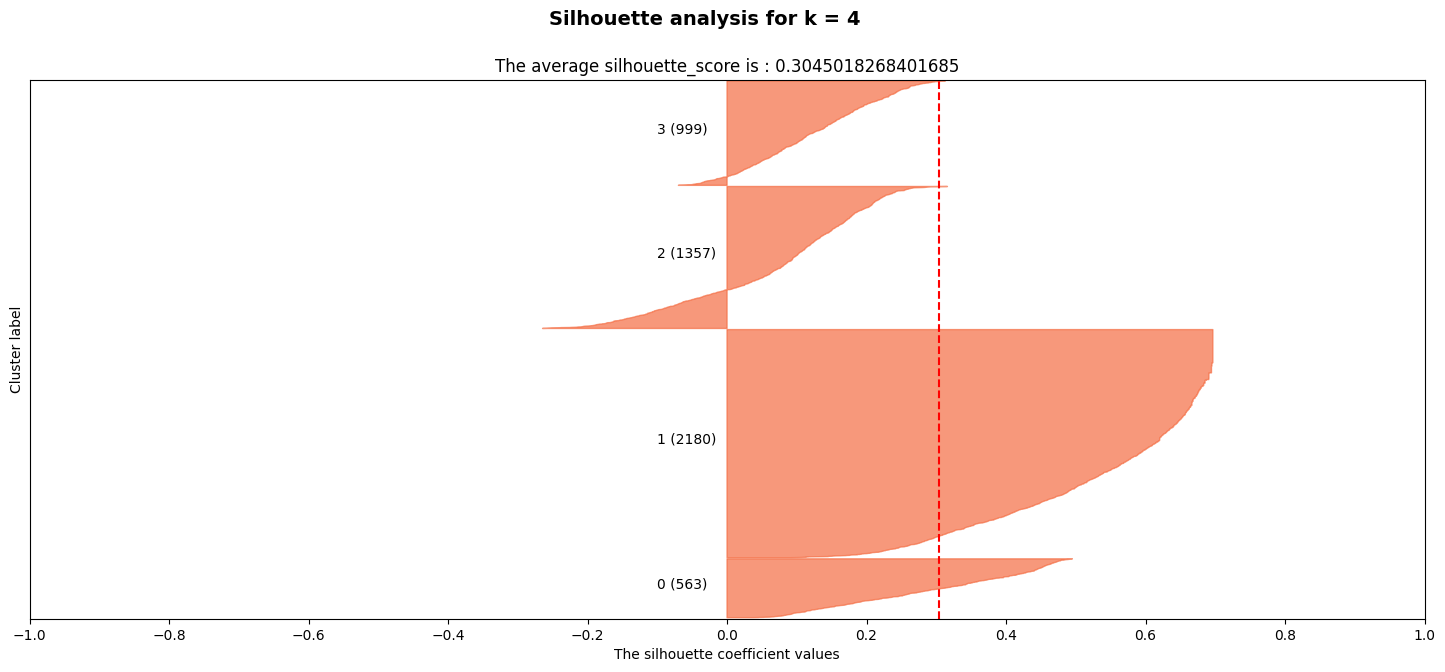

In [59]:
## Compute Results K = 4
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k4']], 4, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.2598224320286133
 Average cluster 0: 0.31683173826845545
 Average cluster 1: 0.5758525804639786
 Average cluster 2: 0.09557441499763052
 Average cluster 3: 0.10754327844972889
 Average cluster 4: 0.09472617844576539


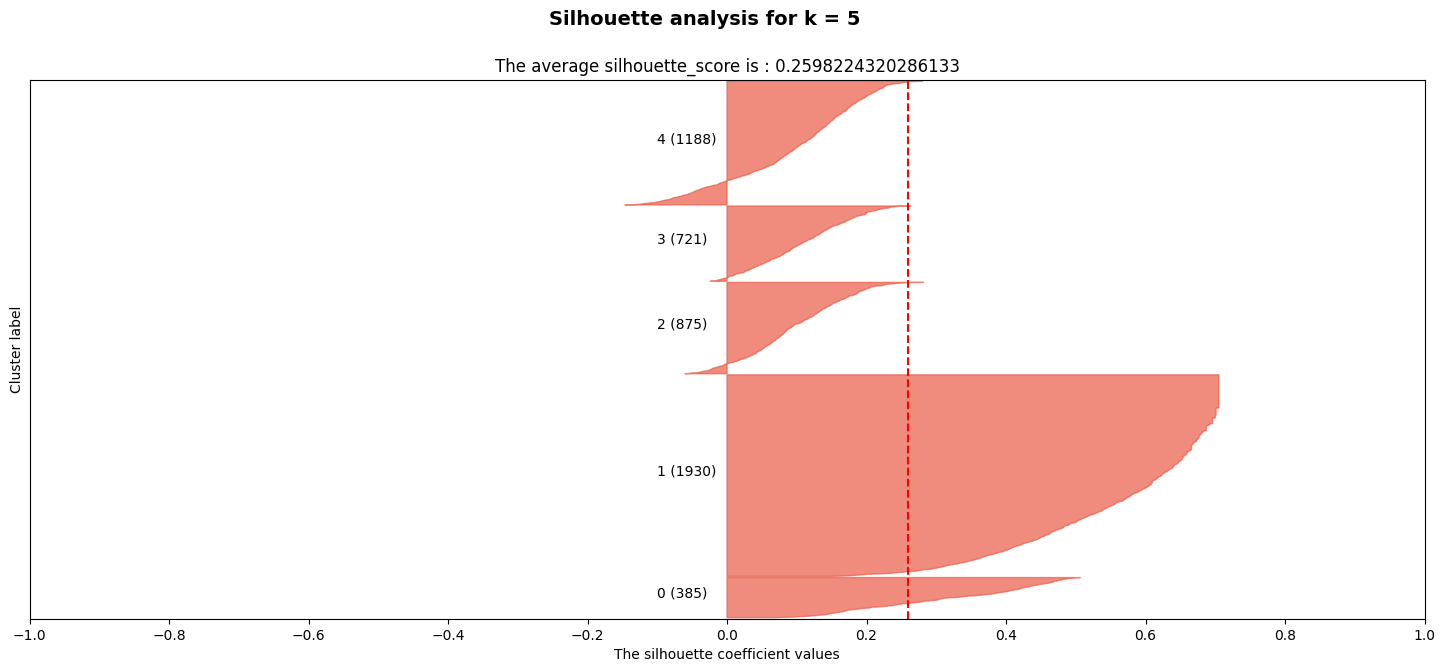

In [60]:
## Compute Results K = 5
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k5']], 5, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.26135703724956216
 Average cluster 0: 0.11173034507135668
 Average cluster 1: 0.5706226804358213
 Average cluster 2: 0.11576582151509632
 Average cluster 3: 0.12628561212006478
 Average cluster 4: 0.10807793439256963
 Average cluster 5: 0.30313568781340744


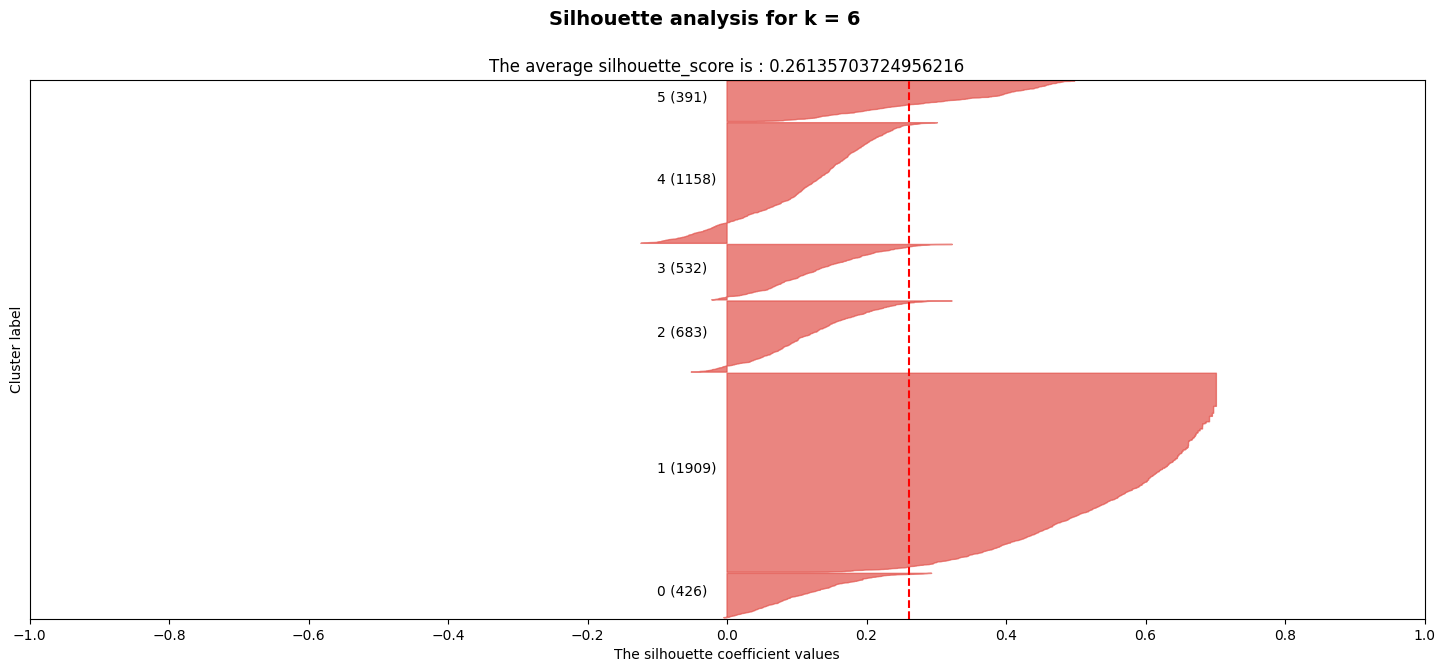

In [61]:
## Compute Results K = 6
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k6']], 6, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.22194778691007747
 Average cluster 0: 0.08839125828557881
 Average cluster 1: 0.5792564600366288
 Average cluster 2: 0.10833941622416887
 Average cluster 3: 0.11477720511174479
 Average cluster 4: 0.0893101940718546
 Average cluster 5: 0.30927274373558034
 Average cluster 6: 0.11060025083402135


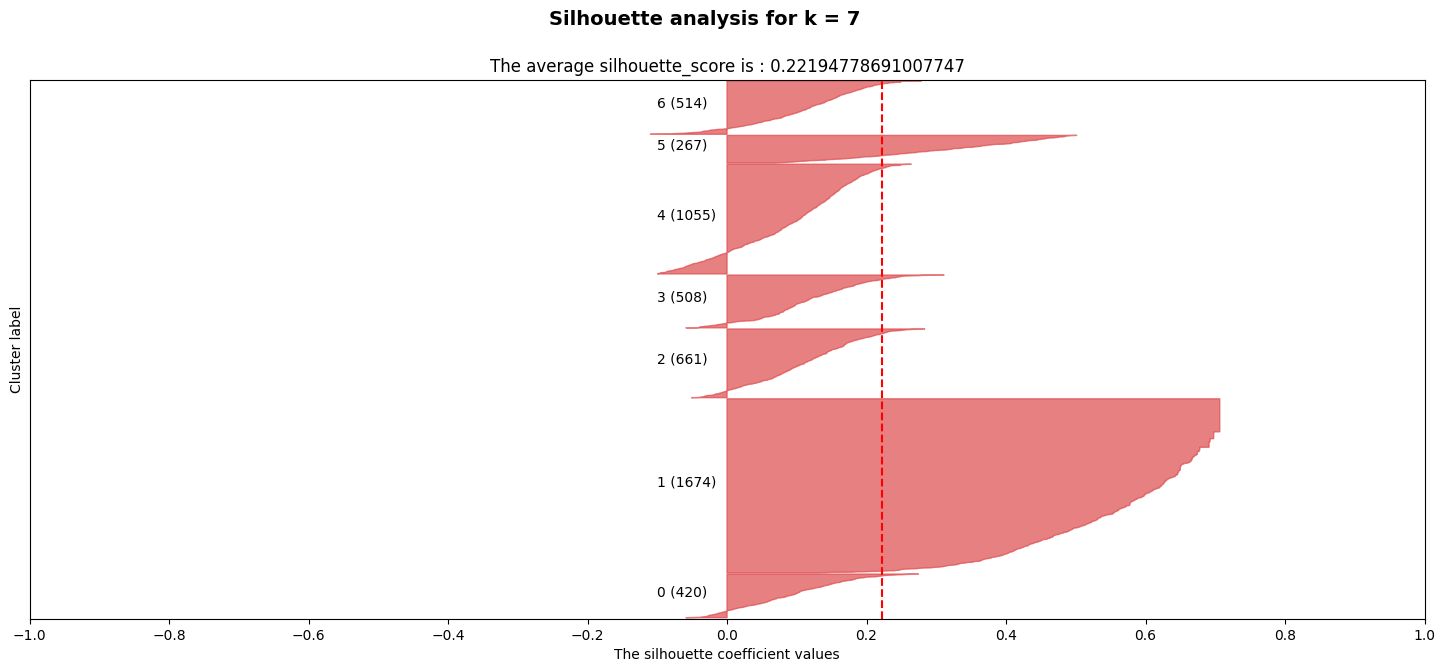

In [62]:
## Compute Results K = 7
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k7']], 7, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.22738464718212137
 Average cluster 0: 0.10582277178859792
 Average cluster 1: 0.5346587576278397
 Average cluster 2: 0.025132954913101316
 Average cluster 3: 0.13726378977461542
 Average cluster 4: 0.3227380031515948
 Average cluster 5: 0.1366063357540179
 Average cluster 6: 0.16658216749138555
 Average cluster 7: 0.15572441228117792


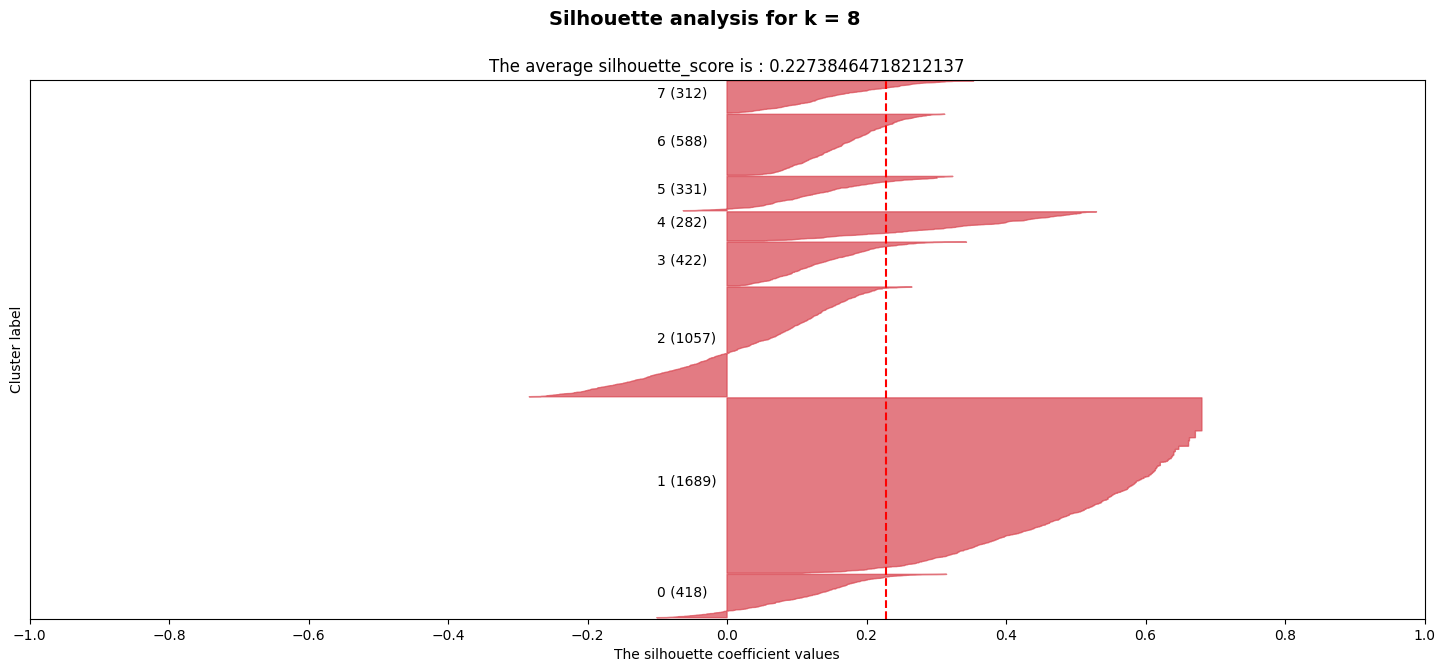

In [63]:
## Compute Results K = 8
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k8']], 8, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.23316035243577712
 Average cluster 0: 0.12604619191286384
 Average cluster 1: 0.5347456690753815
 Average cluster 2: 0.06877118853283504
 Average cluster 3: 0.1277868744989435
 Average cluster 4: 0.3271610387433969
 Average cluster 5: 0.13592326411694466
 Average cluster 6: 0.1679787177680556
 Average cluster 7: 0.16164043075223014
 Average cluster 8: 0.21240773928133902


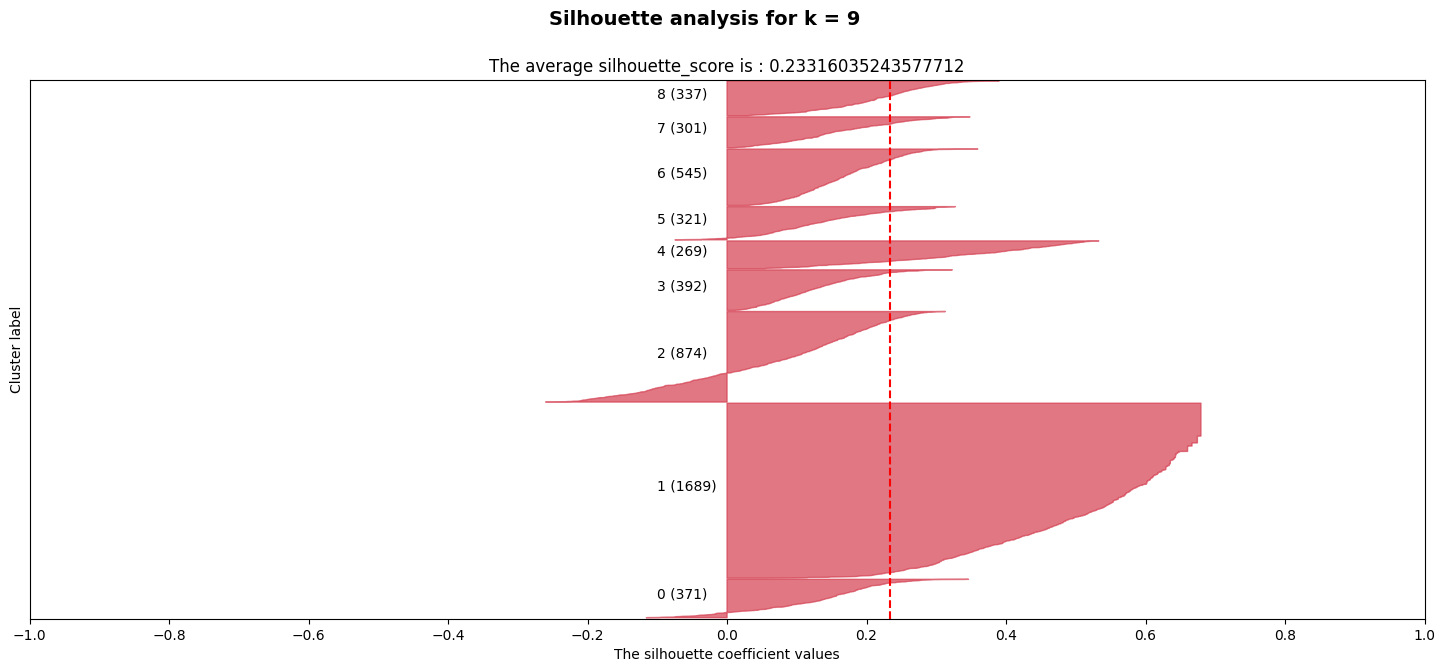

In [64]:
## Compute Results K = 9
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k9']], 9, columns_gp)

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.2292663462864078
 Average cluster 0: 0.16064670989565785
 Average cluster 1: 0.5369461875363285
 Average cluster 2: 0.06707805647075835
 Average cluster 3: 0.13614929757914543
 Average cluster 4: 0.327669332310372
 Average cluster 5: 0.1271468959301606
 Average cluster 6: 0.18521185362665274
 Average cluster 7: 0.15616656848725832
 Average cluster 8: 0.21894545970358836
 Average cluster 9: 0.13124273776235895


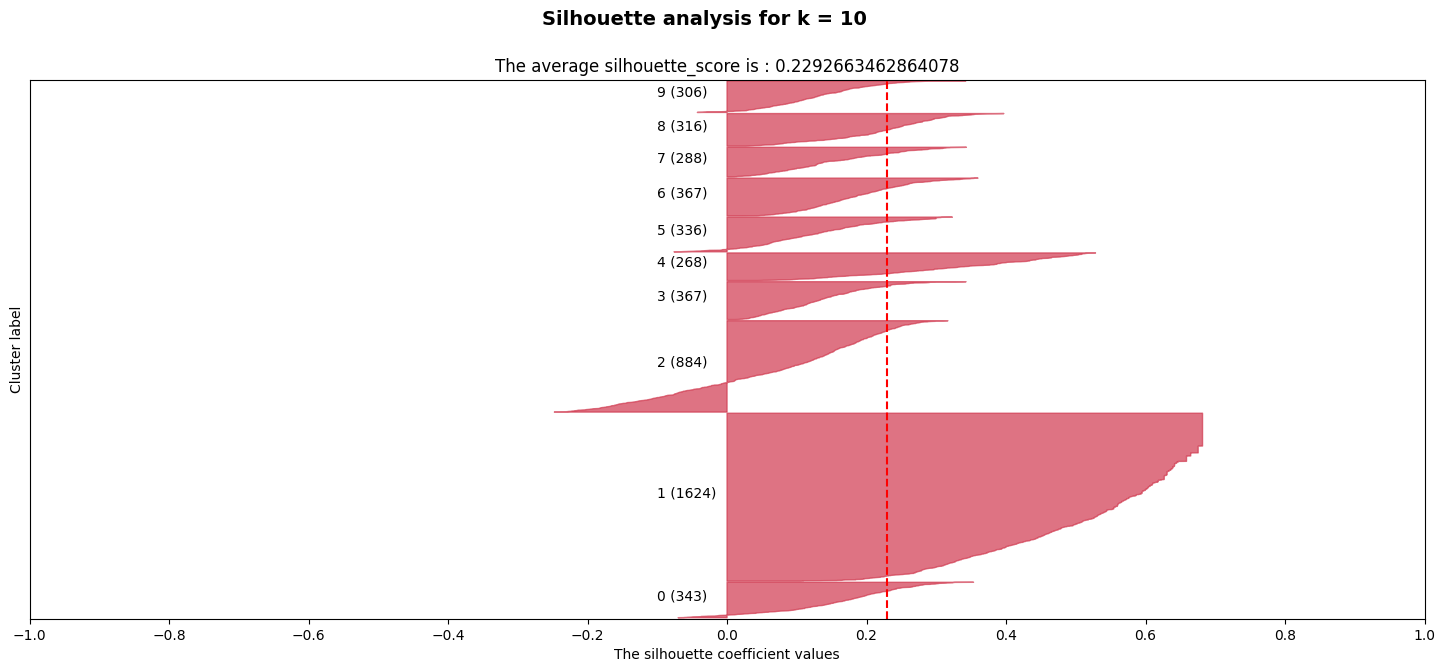

In [65]:
## Compute Results K = 10
compute_silhouette_plot(psaid12[columns_gp + ['clusterID_k10']], 10, columns_gp)

### Robustness

#### Split Sample Validation

In [66]:
# Split sample and generate clusters with datasplit
def split_sample_clustering(data, k, RandomSeed, columns_gp):
    #Split dataset in 2 equal parts
    print('Split sample in half:')
    data_split1, data_split2 = train_test_split(data[['respondentid', 'mm']+ columns_gp], test_size=0.5, random_state=RandomSeed)
    """ Indexes are kept when the dataset is split """

    # Check if both samples have the same shape
    print("Split 1 shape: ", data_split1.shape) 
    print("Split 2 shape: ", data_split2.shape)

    # Run clustering for split 1
    psaid12_split1, cluster_centers_split1 = run_clustering(data_split1, k, RandomSeed, columns_gp)

    # Subset the full cluster analysis based on the indexes of the test dataset
    # And check if the test dataset and the subset of the complete dataset are equal
    split_indexes = data_split1.index # Get indexes of the datapoints included
    data_ss_subset = data[['respondentid', 'mm']+ columns_gp + [f'clusterID_k{k}']].loc[split_indexes] # Subset the full dataset based on these indexes
    print("Complete_subset shape: ", data_ss_subset.shape)
    print(f'Equality between complete_subsetted and split1 is: {data_ss_subset[['respondentid', 'mm'] + columns_gp].equals(data_split1[['respondentid', 'mm'] + columns_gp])} \n') # Check equality True or False
    
    return psaid12_split1, cluster_centers_split1, data_ss_subset

# Establish parity between the assigned clusters generated with the full and split data.
def match_clusters(data1, centers1, data2, centers2, k, columns_gp):
    """
    Function that pairs the cluster centers by closeness. 
    It is used to establish the same cluster codes between algorithms.
    """

    print('Match clusters')

    data1 = data1.copy()
    data2 = data2.copy()
    
    # Find Closest Clusters
    distances = cdist(centers1, centers2, metric='euclidean') #Compute pairwise distances
    print("Pairwise Euclidean distances between cluster centers:\n", distances)
    # print("Each row in the distances matrix corresponds to a cluster from data1. Each column in the distances matrix corresponds to a cluster from data2. \n")

    row_ind, col_ind = linear_sum_assignment(distances) #Match clusters using the Hungarian algorithm
    cluster_mapping = dict(zip(col_ind, row_ind)) # Create a mapping from data1 to data2
    
    print(f'Cluster mapping (data2 -> data1): {cluster_mapping} \n')
 
    ## Remap Cluster Assignments
    def remap_labels(labels, mapping):
        """
        Remap cluster labels based on a mapping dictionary.
        :param labels: Original cluster labels.
        :param mapping: Mapping dictionary (e.g., {0: 1, 1: 0, ...}).
        :return: Remapped cluster labels.
        """
        return np.array([mapping[label] for label in labels])

    data2[f'clusterID_k{k}_OG'] = data2[f'clusterID_k{k}'].astype('category')
    data2[f'clusterID_k{k}'] = remap_labels(data2[f'clusterID_k{k}'], cluster_mapping) #Remap cluser assignments 
    data2[f'clusterID_k{k}'] = data2[f'clusterID_k{k}'].astype('category') # Convert from int to category

    ## Remap Cluster Centers
    cluster_centers = {
        f'data1': [data1.groupby(f'clusterID_k{k}')[columns_gp].mean().values], #Compute cluster means
        f'data2': [data2.groupby(f'clusterID_k{k}')[columns_gp].mean().values]  #Compute cluster means
    }  
    
    # Check if correct
    table = pd.DataFrame({
        f'data1': pd.Series(data1[f'clusterID_k{k}']).value_counts(),
        f'Original {data2} data2': pd.Series(data2[f'clusterID_k{k}_OG']).value_counts(),
        f'Remapped {data2} data2': pd.Series(data2[f'clusterID_k{k}']).value_counts()
    }).sort_index()
    
    # print(table)

    # Define output
    return data2, cluster_centers

# Compute similarity with the Adjusted Rand Index
def compute_ARI(estimator1, estimator2):
    """
    The Adjusted Rand Index (ARI): a measure used to evaluate the similarity between two data clusterings. 
    It is an adjustment of the Rand Index (RI), which counts the number of pairs of elements that are either both in the same cluster or both in different clusters in the predicted and true clusterings. 
    The ARI adjusts for the chance grouping of elements, providing a more accurate measure of clustering similarity. 
    The ARI adjusts the RI by considering the expected similarity of all pairwise comparisons based on chance. 
    This adjustment makes the ARI more reliable and interpretable, especially when comparing different clustering results.
    
    The ARI score ranges from -1 to 1.
    1 = identical clustering 0 = similarity is no better than what would be expected by chance -1 = two clusters are less similar than random clustering (strongly disagreeing)
    """
    ari = adjusted_rand_score(estimator1, estimator2)
    print(f'Adjusted Rand Index: {ari} \n')
    return ari

def split_sample_validation(data, k, RandomSeed, columns_gp, cluster_centers_dict):
    data_split1_clusters, cluster_centers_split1, data_complete_clusters_subset = split_sample_clustering(data, k, RandomSeed, columns_gp)
    data_split1_clusters_matched, cluster_centers_split1_matched = match_clusters(data_complete_clusters_subset, cluster_centers_dict[k], data_split1_clusters, cluster_centers_split1, k, columns_gp)
    ari_completesubset_split1 = compute_ARI(data_split1_clusters_matched[f'clusterID_k{k}'], data_complete_clusters_subset[f'clusterID_k{k}'])
    

In [67]:
split_sample_validation(psaid12, 3, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 4, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 5, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 6, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 7, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 8, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 9, RandomSeed, columns_gp, cluster_centers_dict)
split_sample_validation(psaid12, 10, RandomSeed, columns_gp, cluster_centers_dict)

Split sample in half:
Split 1 shape:  (2549, 14)
Split 2 shape:  (2550, 14)
Complete_subset shape:  (2549, 15)
Equality between complete_subsetted and split1 is: True 

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[18.82435171  0.24455913 10.57058429]
 [ 0.10221053 18.63712528  8.8399843 ]
 [ 9.06690209 10.31696282  0.25090717]]
Cluster mapping (data2 -> data1): {1: 0, 0: 1, 2: 2} 

Adjusted Rand Index: 0.9782637419730486 

Split sample in half:
Split 1 shape:  (2549, 14)
Split 2 shape:  (2550, 14)
Complete_subset shape:  (2549, 15)
Equality between complete_subsetted and split1 is: True 

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[21.55246831  8.3884541  15.31188086  0.16728413]
 [ 0.08082733 14.58720752  7.02733858 21.67172838]
 [ 6.70812033  8.05603022  0.31934643 15.61995983]
 [14.22933987  0.40798604  7.49065163  8.74680589]]
Cluster mapping (data2 -> data1): {3: 0, 0: 1, 2: 2, 1: 3} 

Adjusted Rand Index: 0.9560039493770628 


#### Change RandomSeed

In [68]:
cluster_centers_seed22_dict = {}

def seed_validation(data, RandomSeed, k):
    # Run clustering with differend seed
    psaid12_seedB, cluster_centers_seedB = run_clustering(psaid12[['respondentid', 'mm']+ columns_gp], k, RandomSeed, columns_gp)
    
    # Match Clusters
    psaid12_seedB_matched, cluster_centers_seedB_matched = match_clusters(psaid12, cluster_centers_dict[k], psaid12_seedB, cluster_centers_seedB, k, columns_gp)
    
    # ARI
    ari_seed42_seedB = compute_ARI(psaid12_seedB_matched[f'clusterID_k{k}'], psaid12[f'clusterID_k{k}'])

In [69]:
seed_validation(psaid12, 2, 3)
seed_validation(psaid12, 12, 3)
seed_validation(psaid12, 22, 3)
seed_validation(psaid12, 32, 3)

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[ 0.15194764 18.71100353 10.29441581]
 [18.87761795  0.04219505  9.13731635]
 [10.58768322  8.94683686  0.16378521]]
Cluster mapping (data2 -> data1): {0: 0, 1: 1, 2: 2} 

Adjusted Rand Index: 0.9759490053489863 

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[10.29729403 18.71257293  0.15194764]
 [ 9.13438246  0.0407895  18.87761795]
 [ 0.16127747  8.94858968 10.58768322]]
Cluster mapping (data2 -> data1): {2: 0, 1: 1, 0: 2} 

Adjusted Rand Index: 0.9759490053489863 

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[18.71100353  0.15194764 10.29441581]
 [ 0.04219505 18.87761795  9.13731635]
 [ 8.94683686 10.58768322  0.16378521]]
Cluster mapping (data2 -> data1): {1: 0, 0: 1, 2: 2} 

Adjusted Rand Index: 0.9759490053489863 

Match clusters
Pairwise Euclidean distances between cluster centers:
 [[1.04472339e+01 8.88178420e-16 1.87472049e+01]
 [8.98709941e+00 1.87472049

/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

#### Leave one variable out

In [70]:
def variable_validation(data, Randomseed, k, varlist):
    # Run clustering with different var
    psaid12_varlistB, cluster_centers_varlistB = run_clustering(psaid12[['respondentid', 'mm']+ varlist], k, RandomSeed, varlist)

    # Compute cluster centers of complete dataset without missing var
    cluster_centers_complete_varlistB = data.groupby(f'clusterID_k{k}')[varlist].mean().values
    
    # Match Clusters
    psaid12_varlistB_matched, cluster_centers_varlistB_matched = match_clusters(psaid12, cluster_centers_complete_varlistB, psaid12_varlistB, cluster_centers_varlistB, k, varlist)
    
    # ARI
    ari_columns_gp_varlistB = compute_ARI(psaid12_varlistB_matched[f'clusterID_k{k}'], psaid12[f'clusterID_k{k}'])
    return ari_columns_gp_varlistB 

In [71]:
## Define Varlists
ari_varlists_dict = {}

for k in range(3,8):
    print(f'kmeans_{k}')
    for var in columns_gp:
        varlistB = [i for i in psaid12.columns if re.match(r'^gp\d{2}$', i) and i != var]
        ari_varlists_dict[f'no {var}']  = suppress_prints(variable_validation, psaid12, RandomSeed, k, varlistB) # Store ARI values in dictionary
        print(f'ARI = {round(ari_varlists_dict[f'no {var}'], 3)} without {var} ({domains_dict[var]})')

/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

kmeans_3
ARI = 0.913 without gp01 (Pain)
ARI = 0.878 without gp02 (Fatigue)
ARI = 0.952 without gp03 (Skin)
ARI = 0.912 without gp04 (Work-recreational activities)
ARI = 0.922 without gp05 (Bodily functioning)
ARI = 0.913 without gp06 (Discomfort)
ARI = 0.908 without gp07 (Sleep)
ARI = 0.934 without gp08 (Coping)
ARI = 0.927 without gp09 (Anxiety)
ARI = 0.959 without gp10 (Shame)


/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

ARI = 0.953 without gp11 (Social activities)
ARI = 0.948 without gp12 (Depression)
kmeans_4
ARI = 0.878 without gp01 (Pain)
ARI = 0.86 without gp02 (Fatigue)
ARI = 0.916 without gp03 (Skin)
ARI = 0.906 without gp04 (Work-recreational activities)
ARI = 0.919 without gp05 (Bodily functioning)


/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

...

/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

ARI = 0.902 without gp05 (Bodily functioning)
ARI = 0.899 without gp06 (Discomfort)
ARI = 0.874 without gp07 (Sleep)
ARI = 0.84 without gp08 (Coping)
ARI = 0.76 without gp09 (Anxiety)
ARI = 0.906 without gp10 (Shame)
ARI = 0.87 without gp11 (Social activities)
ARI = 0.891 without gp12 (Depression)
kmeans_7
ARI = 0.753 without gp01 (Pain)
ARI = 0.679 without gp02 (Fatigue)


/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

ARI = 0.82 without gp03 (Skin)
ARI = 0.797 without gp04 (Work-recreational activities)
ARI = 0.811 without gp05 (Bodily functioning)
ARI = 0.743 without gp06 (Discomfort)
ARI = 0.687 without gp07 (Sleep)
ARI = 0.818 without gp08 (Coping)
ARI = 0.719 without gp09 (Anxiety)
ARI = 0.779 without gp10 (Shame)
ARI = 0.774 without gp11 (Social activities)
ARI = 0.792 without gp12 (Depression)


/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the psaid12 dataframe
/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_58128/2280656424.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'clusterID_k{n_clusters}'] = kmeans.fit_predict(data[byvar]) #Assign cluster to each datapoint and store in the 

# Save Clustering results, K = [3, 6]

In [72]:
folder_path = data_storage
file_name = "PsAID_KMeans++_Clusters"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
psaid12.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_KMeans++/PsAID_KMeans++_Clusters.csv
